C:\Users\hii\anaconda3\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


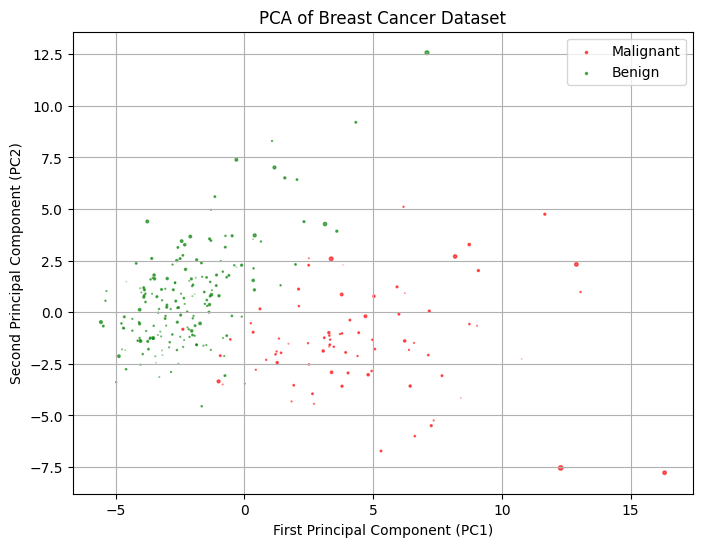

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
brest_dataset = load_breast_cancer()

# 2. Pass the data and column names to the DataFrame constructor
df = pd.DataFrame(brest_dataset.data , columns=brest_dataset.feature_names )
scaler = StandardScaler() # preprocessing of the data with the mean and the standard deviation and calculate the z-score of the data
df_scaler = scaler.fit_transform(df)
prca = PCA(n_components = 2) # dimensionality reduction of the data 
df_prca = prca.fit_transform(df_scaler)
prca_dataframe = pd.DataFrame(df_prca , columns = ['PC1','PC2'] )
prca_dataframe['target'] = brest_dataset.target
plt.figure(figsize=(8, 6))
targets = [0, 1]
colors = ["r", "g"]
labels = ["Malignant", "Benign"]
for target, color, label in zip(targets, colors, labels):
    indices = prca_dataframe["target"] == target
    plt.scatter(
        prca_dataframe.loc[indices, "PC1"],
        prca_dataframe.loc[indices, "PC2"],
        c=color,
        label=label,
        alpha=0.6,
    )
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("PCA of Breast Cancer Dataset")
plt.legend()
plt.grid(True)
plt.show()
print(df)
print("-------------------------------------------------------------------------------------------------------")
print(df_scaler)
print("-------------------------------------------------------------------------------------------------------")
print(df_prca)
print("-------------------------------------------------------------------------------------------------------")
print(prca_dataframe)